# 📘 Day 4 (Morning) — Data Analysis with Pandas
**SDNB Vaishnav College for Women, Chromepet**

**Date:** Thursday, 30 April 2026 | **Duration:** 9:30 AM – 1:00 PM

---

### 🎯 By the end of this morning you will:
- ✅ Read CSV files into Pandas and explore them
- ✅ Analyse `sales_data.csv` end-to-end (revenue, top performers, charts)
- ✅ Build a **7-day weekly sales report** in both plain Python and Pandas
- ✅ Reconcile a `bank_transactions.csv` automatically
- ✅ Manage `inventory.csv` — read, add new product, save back

In [1]:
# ── Install & Setup (run this first on Google Colab) ──
import sys, os

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    print("✅ All libraries ready!")
except ImportError as e:
    print(f"Installing missing library: {e}")
    os.system("pip install pandas matplotlib numpy seaborn -q")
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

# Where the CSV data files live.
# - On Colab after uploading the workshop folder: "/content/sdnb_python_workshop/data/"
# - When running locally from notebooks/ folder:   "../data/"
DATA_PATH = "../data/" if os.path.exists("../data") else "data/"
print(f"📁 Using data path: {DATA_PATH}")

✅ All libraries ready!
📁 Using data path: ../data/


## 🔁 Quick Recap — Day 3

We learned to **draw** with Matplotlib. Today we learn to **analyse** with Pandas. The two tools work hand in hand: Pandas reshapes the data, Matplotlib displays it.

## 🐼 Section 1 — Introduction to Pandas *(25 min)*

> **Analogy:** Pandas is **Excel inside Python**. A *DataFrame* is exactly like an Excel sheet — rows, columns, filters, formulas. Except it can handle 10 MILLION rows without crashing, and you can automate everything.

| What you do in Excel | What you do in Pandas |
|----------------------|------------------------|
| Open a `.csv` file | `pd.read_csv("file.csv")` |
| See first 5 rows | `df.head()` |
| See column names | `df.columns` |
| Filter rows (AutoFilter) | `df[df["Sales"] > 5000]` |
| Sum a column | `df["Sales"].sum()` |
| Group by category | `df.groupby("Category").sum()` |
| Sort by column | `df.sort_values("Amount")` |
| Add new column (formula) | `df["Tax"] = df["Price"] * 0.18` |

In [2]:
import pandas as pd

# 1) Build a tiny DataFrame from scratch (5 rows × 4 cols)
mini = pd.DataFrame({
    "Date"   : ["27-Apr", "27-Apr", "28-Apr", "28-Apr", "29-Apr"],
    "Product": ["Saree", "Kurti", "Watch", "Bedsheet", "Saree"],
    "Units"  : [3, 5, 2, 4, 6],
    "Price"  : [2499, 1299, 3499, 1199, 2499],
})
print(mini)

     Date   Product  Units  Price
0  27-Apr     Saree      3   2499
1  27-Apr     Kurti      5   1299
2  28-Apr     Watch      2   3499
3  28-Apr  Bedsheet      4   1199
4  29-Apr     Saree      6   2499


In [3]:
# 2) The basic inspection toolkit
print("\nhead(3):"); print(mini.head(3))
print("\ntail(2):"); print(mini.tail(2))
print("\nshape  :", mini.shape, "(rows, cols)")
print("\ndtypes :"); print(mini.dtypes)
print("\ncolumns:", list(mini.columns))
print("\ndescribe (numeric only):"); print(mini.describe())


head(3):
     Date Product  Units  Price
0  27-Apr   Saree      3   2499
1  27-Apr   Kurti      5   1299
2  28-Apr   Watch      2   3499

tail(2):
     Date   Product  Units  Price
3  28-Apr  Bedsheet      4   1199
4  29-Apr     Saree      6   2499

shape  : (5, 4) (rows, cols)

dtypes :
Date       object
Product    object
Units       int64
Price       int64
dtype: object

columns: ['Date', 'Product', 'Units', 'Price']

describe (numeric only):
          Units        Price
count  5.000000     5.000000
mean   4.000000  2199.000000
std    1.581139   959.166305
min    2.000000  1199.000000
25%    3.000000  1299.000000
50%    4.000000  2499.000000
75%    5.000000  2499.000000
max    6.000000  3499.000000


In [4]:
# 3) Selecting, filtering, calculating
print("Single column:"); print(mini["Product"], "\n")

# Filter rows where Units > 3
print("Rows with Units > 3:")
print(mini[mini["Units"] > 3], "\n")

# Add a calculated column
mini["Revenue"] = mini["Units"] * mini["Price"]
print("With Revenue column:")
print(mini)

Single column:
0       Saree
1       Kurti
2       Watch
3    Bedsheet
4       Saree
Name: Product, dtype: object 

Rows with Units > 3:
     Date   Product  Units  Price
1  27-Apr     Kurti      5   1299
3  28-Apr  Bedsheet      4   1199
4  29-Apr     Saree      6   2499 

With Revenue column:
     Date   Product  Units  Price  Revenue
0  27-Apr     Saree      3   2499     7497
1  27-Apr     Kurti      5   1299     6495
2  28-Apr     Watch      2   3499     6998
3  28-Apr  Bedsheet      4   1199     4796
4  29-Apr     Saree      6   2499    14994


In [5]:
# 4) iloc vs loc
print("First row by position (iloc[0]):")
print(mini.iloc[0], "\n")

print("Cell at row 2, column 'Product' (loc):")
print(mini.loc[2, "Product"])

First row by position (iloc[0]):
Date       27-Apr
Product     Saree
Units           3
Price        2499
Revenue      7497
Name: 0, dtype: object 

Cell at row 2, column 'Product' (loc):
Watch


In [6]:
# 5) Missing values
import numpy as np
sample = pd.DataFrame({"Item": ["A", "B", "C"], "Stock": [10, np.nan, 0]})
print("With missing values:"); print(sample)
print("\nisnull():"); print(sample.isnull())
print("\nfillna(0):"); print(sample.fillna(0))
print("\ndropna():"); print(sample.dropna())

With missing values:
  Item  Stock
0    A   10.0
1    B    NaN
2    C    0.0

isnull():
    Item  Stock
0  False  False
1  False   True
2  False  False

fillna(0):
  Item  Stock
0    A   10.0
1    B    0.0
2    C    0.0

dropna():
  Item  Stock
0    A   10.0
2    C    0.0


**🧠 What just happened?** `fillna()` is like *filling blank cells in your attendance register* — it replaces missing values. `dropna()` removes any row that has missing data.

## 📊 Exercise 1 — Sales CSV Analysis *(30 min)*

Load `sales_data.csv` and do a full analysis.

In [7]:
try:
    sales = pd.read_csv(DATA_PATH + "sales_data.csv")
    print(f"✅ Loaded {len(sales)} sales records")
except FileNotFoundError:
    print("⚠️ File not found at", DATA_PATH)
    raise

# Step 1 — Data overview
print("\nShape   :", sales.shape)
print("Columns :", list(sales.columns))
print("\nFirst 5 rows:"); print(sales.head())
print("\nMissing values per column:"); print(sales.isnull().sum())
print("\ndescribe():"); print(sales.describe())

✅ Loaded 90 sales records

Shape   : (90, 6)
Columns : ['Date', 'Product', 'Category', 'Units', 'Price', 'Region']

First 5 rows:
         Date             Product    Category  Units    Price           Region
0  2026-01-07  Filter Coffee 500g   Groceries    4.0   303.23            Salem
1  2026-01-02   Notebook A4 200pg  Stationery    6.0    86.76          Chennai
2  2026-02-19     Bedsheet Double    Textiles    4.0  1243.07  Tiruchirappalli
3  2026-03-25      Bridal Lehenga    Textiles    6.0  9248.23            Salem
4  2026-01-28       Ball Pen Pack  Stationery   15.0    47.35       Coimbatore

Missing values per column:
Date        0
Product     0
Category    0
Units       2
Price       0
Region      1
dtype: int64

describe():
            Units        Price
count   88.000000    90.000000
mean    15.454545  1441.517444
std     26.424870  2431.126405
min      1.000000    47.050000
25%      6.000000   148.602500
50%     13.500000   407.495000
75%     20.000000  1295.290000
max    250

In [8]:
# Clean: coerce Units to numeric and drop missing units
sales["Units"] = pd.to_numeric(sales["Units"], errors="coerce")
sales_clean = sales.dropna(subset=["Units"]).copy()
sales_clean["Units"] = sales_clean["Units"].astype(int)

# Step 2 — Revenue analysis
sales_clean["Revenue"] = sales_clean["Units"] * sales_clean["Price"]
total_revenue = sales_clean["Revenue"].sum()
print(f"Total revenue across {len(sales_clean)} rows: ₹{total_revenue:,.2f}")

# Revenue by Category
rev_by_cat = sales_clean.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
print("\nRevenue by Category:")
print(rev_by_cat.apply(lambda v: f"₹{v:,.0f}"))

# Revenue by Region (handle missing)
rev_by_region = sales_clean.assign(Region=sales_clean["Region"].fillna("Unknown")) \
    .groupby("Region")["Revenue"].sum().sort_values(ascending=False)
print("\nRevenue by Region:")
print(rev_by_region.apply(lambda v: f"₹{v:,.0f}"))

Total revenue across 88 rows: ₹1,583,114.88

Revenue by Category:
Category
Textiles       ₹1,188,372
Electronics      ₹271,091
Groceries         ₹73,228
Stationery        ₹50,424
Name: Revenue, dtype: object

Revenue by Region:
Region
Chennai            ₹575,247
Tiruchirappalli    ₹299,199
Coimbatore         ₹255,348
Madurai            ₹240,317
Salem              ₹192,166
Unknown             ₹20,838
Name: Revenue, dtype: object


In [9]:
# Revenue by Month
sales_clean["Date"] = pd.to_datetime(sales_clean["Date"], errors="coerce")
sales_clean["Month"] = sales_clean["Date"].dt.month_name().str[:3]
rev_by_month = sales_clean.groupby("Month", sort=False)["Revenue"].sum()

# Sort months chronologically
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
rev_by_month = rev_by_month.reindex([m for m in month_order if m in rev_by_month.index])
print("\nRevenue by Month:")
print(rev_by_month.apply(lambda v: f"₹{v:,.0f}"))


Revenue by Month:
Month
Jan    ₹608,511
Feb    ₹662,072
Mar    ₹312,532
Name: Revenue, dtype: object


In [10]:
# Step 3 — Top performers
top_products = sales_clean.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(5)
top_regions  = sales_clean.assign(Region=sales_clean["Region"].fillna("Unknown")) \
                          .groupby("Region")["Revenue"].sum().sort_values(ascending=False).head(3)
best_month   = rev_by_month.idxmax()
worst_month  = rev_by_month.idxmin()

print("Top 5 products by revenue:")
print(top_products.apply(lambda v: f"₹{v:,.0f}"))
print("\nTop 3 regions:")
print(top_regions.apply(lambda v: f"₹{v:,.0f}"))
print(f"\nBest performing month  : {best_month}  (₹{rev_by_month.max():,.0f})")
print(f"Worst performing month : {worst_month} (₹{rev_by_month.min():,.0f})")

Top 5 products by revenue:
Product
Bridal Lehenga       ₹837,091
Kurti Set            ₹191,605
Smart Watch          ₹132,037
Bluetooth Speaker     ₹98,086
Cotton Saree          ₹90,789
Name: Revenue, dtype: object

Top 3 regions:
Region
Chennai            ₹575,247
Tiruchirappalli    ₹299,199
Coimbatore         ₹255,348
Name: Revenue, dtype: object

Best performing month  : Feb  (₹662,072)
Worst performing month : Mar (₹312,532)


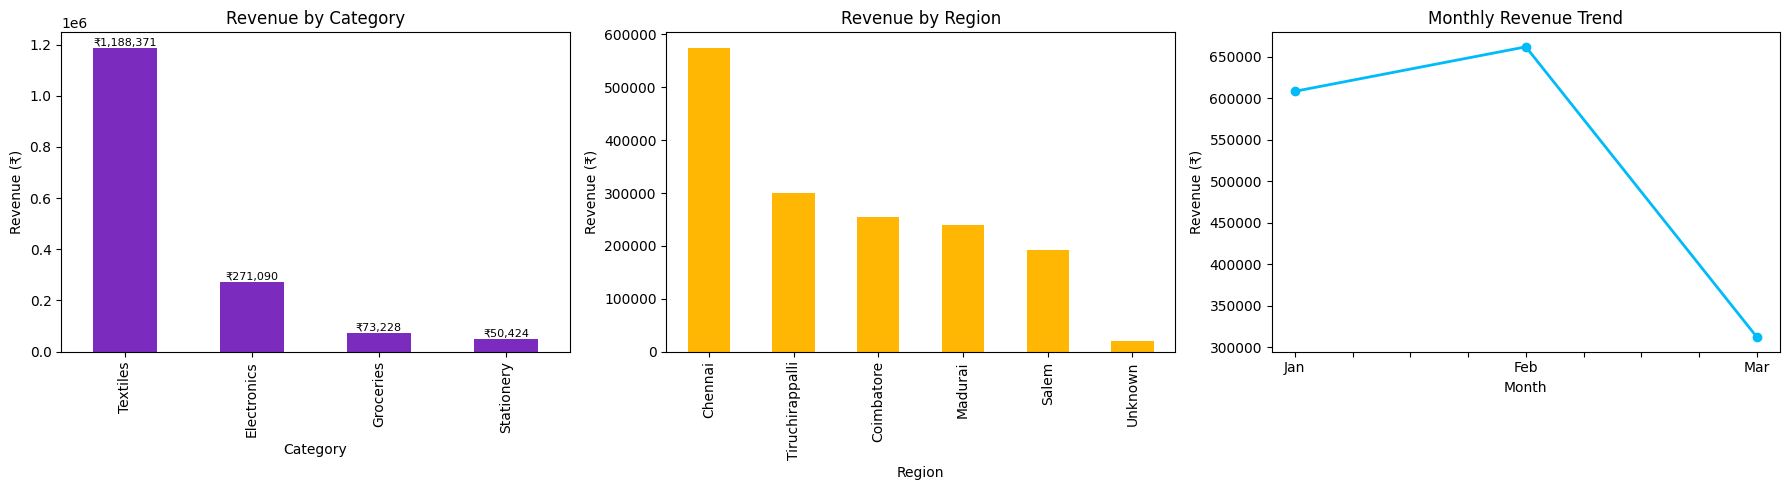

In [11]:
# Step 4 — Visualise findings
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rev_by_cat.plot(kind="bar", ax=axes[0], color="#7B2CBF",
                title="Revenue by Category")
axes[0].set_ylabel("Revenue (₹)")
for i, v in enumerate(rev_by_cat.values):
    axes[0].text(i, v, f"₹{int(v):,}", ha="center", va="bottom", fontsize=8)

rev_by_region.plot(kind="bar", ax=axes[1], color="#FFB703",
                   title="Revenue by Region")
axes[1].set_ylabel("Revenue (₹)")

rev_by_month.plot(kind="line", marker="o", ax=axes[2], color="#00BBF9",
                  title="Monthly Revenue Trend", linewidth=2)
axes[2].set_ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

### 📋 Sales Analysis Report — Summary

In [12]:
print("════════════════════════════════════════════════")
print("           SALES ANALYSIS REPORT — Q1 2026     ")
print("════════════════════════════════════════════════")
print(f"  Total Revenue      : ₹{total_revenue:,.2f}")
print(f"  Records analysed   : {len(sales_clean)} (after cleaning)")
print(f"  Best month         : {best_month}")
print(f"  Worst month        : {worst_month}")
print(f"  Top category       : {rev_by_cat.idxmax()} (₹{rev_by_cat.max():,.0f})")
print(f"  Top region         : {rev_by_region.idxmax()} (₹{rev_by_region.max():,.0f})")
print(f"  #1 product         : {top_products.index[0]} (₹{top_products.iloc[0]:,.0f})")
print("════════════════════════════════════════════════")

════════════════════════════════════════════════
           SALES ANALYSIS REPORT — Q1 2026     
════════════════════════════════════════════════
  Total Revenue      : ₹1,583,114.88
  Records analysed   : 88 (after cleaning)
  Best month         : Feb
  Worst month        : Mar
  Top category       : Textiles (₹1,188,372)
  Top region         : Chennai (₹575,247)
  #1 product         : Bridal Lehenga (₹837,091)
════════════════════════════════════════════════


## 📅 Exercise 2 — 7-Day Sales Summary *(20 min)*

**Scenario:** *Week-end review at a Chennai retail store. The manager wants a quick weekly performance summary.*

We'll do this **two ways** — once with plain Python (yesterday's tools), once with Pandas — to feel the difference.

In [13]:
# ── INTERACTIVE VERSION (uncomment to use input()) ──
# weekly_sales = []
# i = 1
# while i <= 7:
#     amt = float(input(f"Enter Day {i} sales: ₹"))
#     weekly_sales.append(amt)
#     i += 1

# Hardcoded so the notebook runs end-to-end
weekly_sales = [28400, 31200, 19800, 42500, 38900, 51200, 15300]
day_names    = ["Monday", "Tuesday", "Wednesday", "Thursday",
                "Friday", "Saturday", "Sunday"]

# ── Plain Python ──
total_p   = sum(weekly_sales)
avg_p     = total_p / len(weekly_sales)
max_p     = max(weekly_sales)
min_p     = min(weekly_sales)
best_idx  = weekly_sales.index(max_p)
worst_idx = weekly_sales.index(min_p)
print(f"Plain Python  →  total ₹{total_p:,} | avg ₹{avg_p:,.0f} | best {day_names[best_idx]} | worst {day_names[worst_idx]}")

# ── Pandas ──
s = pd.Series(weekly_sales, index=day_names, name="Sales")
print(f"Pandas        →  total ₹{s.sum():,} | avg ₹{s.mean():,.0f} | "
      f"best {s.idxmax()} | worst {s.idxmin()}")

Plain Python  →  total ₹227,300 | avg ₹32,471 | best Saturday | worst Sunday
Pandas        →  total ₹227,300 | avg ₹32,471 | best Saturday | worst Sunday


In [14]:
# Pretty weekly summary report with ASCII bar chart
above_avg = sum(1 for x in weekly_sales if x > avg_p)
max_val   = max(weekly_sales)

print("════════════════════════════════════════")
print("     WEEKLY SALES REPORT                ")
print("     Chennai Retail Store | Week 17, 2026")
print("════════════════════════════════════════")

for day, sale in zip(day_names, weekly_sales):
    bar_len = int(round((sale / max_val) * 10))
    bar     = "▓" * bar_len + "░" * (10 - bar_len)
    flag    = " ← BEST DAY" if sale == max_val else (" ← WORST" if sale == min_p else "")
    print(f"  {day:<10s}: ₹{sale:>7,}  [{bar}]{flag}")

print("─────────────────────────────────────────")
print(f"  Total       : ₹{total_p:,}")
print(f"  Average     : ₹{avg_p:,.0f}")
print(f"  Best Day    : {day_names[best_idx]} (₹{max_p:,})")
print(f"  Worst Day   : {day_names[worst_idx]} (₹{min_p:,})")
print(f"  Above avg   : {above_avg} of 7 days")
print("════════════════════════════════════════")

════════════════════════════════════════
     WEEKLY SALES REPORT                
     Chennai Retail Store | Week 17, 2026
════════════════════════════════════════
  Monday    : ₹ 28,400  [▓▓▓▓▓▓░░░░]
  Tuesday   : ₹ 31,200  [▓▓▓▓▓▓░░░░]
  Wednesday : ₹ 19,800  [▓▓▓▓░░░░░░]
  Thursday  : ₹ 42,500  [▓▓▓▓▓▓▓▓░░]
  Friday    : ₹ 38,900  [▓▓▓▓▓▓▓▓░░]
  Saturday  : ₹ 51,200  [▓▓▓▓▓▓▓▓▓▓] ← BEST DAY
  Sunday    : ₹ 15,300  [▓▓▓░░░░░░░] ← WORST
─────────────────────────────────────────
  Total       : ₹227,300
  Average     : ₹32,471
  Best Day    : Saturday (₹51,200)
  Worst Day   : Sunday (₹15,300)
  Above avg   : 3 of 7 days
════════════════════════════════════════


## 🏦 Exercise 3 — Bank Transaction CSV Parser *(25 min)*

**Scenario:** *The accounts assistant at SDNB College needs to reconcile the bank statement. Build an automated analyser.*

In [15]:
bank = pd.read_csv(DATA_PATH + "bank_transactions.csv")
print(f"✅ Loaded {len(bank)} transactions")

# Replace blanks with 0 for arithmetic
bank["Debit"]  = pd.to_numeric(bank["Debit"],   errors="coerce").fillna(0)
bank["Credit"] = pd.to_numeric(bank["Credit"],  errors="coerce").fillna(0)
bank["Balance"]= pd.to_numeric(bank["Balance"], errors="coerce")
bank["Date"]   = pd.to_datetime(bank["Date"], errors="coerce")
bank.head()

✅ Loaded 60 transactions


,Date,Description,Debit,Credit,Balance
0,2026-01-01,Annual Day Expenses,2562.25,0.00,1497437.75
1,2026-01-03,Govt Grant Disbursed,0.00,109041.65,1606479.40
2,2026-01-05,Books Purchase,60715.95,0.00,1545763.45
3,2026-01-07,Cleaning Services,34537.26,0.00,1511226.19
4,2026-01-09,Workshop Income,0.00,175028.52,1686254.71


In [16]:
credit_count = (bank["Credit"] > 0).sum()
debit_count  = (bank["Debit"]  > 0).sum()
total_credits= bank["Credit"].sum()
total_debits = bank["Debit"].sum()

largest_credit = bank.loc[bank["Credit"].idxmax()]
largest_debit  = bank.loc[bank["Debit"].idxmax()]

avg_credit = bank.loc[bank["Credit"] > 0, "Credit"].mean()
avg_debit  = bank.loc[bank["Debit"]  > 0, "Debit"].mean()

big_txns = bank[(bank["Credit"] > 50000) | (bank["Debit"] > 50000)]

print("════════════════════════════════════════════════════════")
print("             BANK RECONCILIATION STATEMENT             ")
print("             SDNB COLLEGE — Period: Jan 2026          ")
print("════════════════════════════════════════════════════════")
print(f"  Total transactions   : {len(bank)}")
print(f"  Credit entries       : {credit_count}")
print(f"  Debit entries        : {debit_count}")
print("--------------------------------------------------------")
print(f"  Total credits        : ₹{total_credits:>14,.2f}")
print(f"  Total debits         : ₹{total_debits:>14,.2f}")
print(f"  Net flow             : ₹{total_credits - total_debits:>14,.2f}")
print("--------------------------------------------------------")
print(f"  Largest credit       : ₹{largest_credit['Credit']:,.2f} ({largest_credit['Description']})")
print(f"  Largest debit        : ₹{largest_debit['Debit']:,.2f} ({largest_debit['Description']})")
print(f"  Avg credit           : ₹{avg_credit:,.2f}")
print(f"  Avg debit            : ₹{avg_debit:,.2f}")
print("--------------------------------------------------------")
print(f"  Transactions > ₹50k  : {len(big_txns)}")
print("════════════════════════════════════════════════════════")

════════════════════════════════════════════════════════
             BANK RECONCILIATION STATEMENT             
             SDNB COLLEGE — Period: Jan 2026          
════════════════════════════════════════════════════════
  Total transactions   : 60
  Credit entries       : 23
  Debit entries        : 37
--------------------------------------------------------
  Total credits        : ₹  4,246,942.78
  Total debits         : ₹  1,682,665.11
  Net flow             : ₹  2,564,277.67
--------------------------------------------------------
  Largest credit       : ₹324,129.08 (Fee Collection - Semester)
  Largest debit        : ₹94,418.30 (Lab Equipment)
  Avg credit           : ₹184,649.69
  Avg debit            : ₹45,477.44
--------------------------------------------------------
  Transactions > ₹50k  : 37
════════════════════════════════════════════════════════



Monthly inflows vs outflows:
              Credit          Debit
Month                              
Jan    ₹   1,645,527  ₹     360,983
Feb    ₹     439,206  ₹     472,764
Mar    ₹   1,429,148  ₹     473,908
Apr    ₹     733,061  ₹     375,010


C:\Users\Surya\AppData\Local\Temp\ipykernel_39372\77411964.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(monthly.applymap(lambda v: f"₹{v:>12,.0f}"))


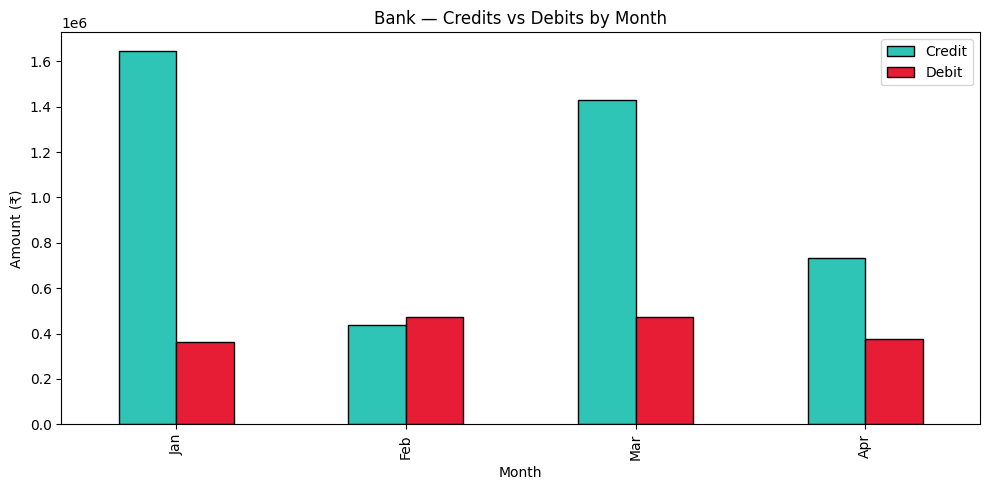

In [17]:
# Monthly summary
bank["Month"] = bank["Date"].dt.month_name().str[:3]
monthly = bank.groupby("Month")[["Credit", "Debit"]].sum()
monthly = monthly.reindex([m for m in ["Jan","Feb","Mar","Apr","May","Jun"] if m in monthly.index])

print("\nMonthly inflows vs outflows:")
print(monthly.applymap(lambda v: f"₹{v:>12,.0f}"))

# Bar chart
import matplotlib.pyplot as plt
ax = monthly.plot(kind="bar", figsize=(10, 5),
                  color=["#2EC4B6", "#E71D36"], edgecolor="black")
ax.set_title("Bank — Credits vs Debits by Month")
ax.set_ylabel("Amount (₹)")
plt.tight_layout()
plt.show()

## 📦 Exercise 4 — Inventory File Management *(20 min)*

Load `inventory.csv`, find low-stock items, append a new product, save back.

In [18]:
inv = pd.read_csv(DATA_PATH + "inventory.csv")
print(f"✅ Loaded {len(inv)} inventory items")
inv.head()

✅ Loaded 30 inventory items


,ProductID,Name,Category,Stock,UnitPrice
0,P001,Silk Saree - Red,Textiles,18,2499.0
1,P002,Silk Saree - Green,Textiles,5,2499.0
2,P003,Cotton Saree Pack,Textiles,42,899.0
3,P004,Bridal Lehenga,Textiles,3,8999.0
4,P005,Kurti - Medium,Textiles,25,1299.0


In [19]:
# Part A — value & alerts
inv["StockValue"] = inv["Stock"] * inv["UnitPrice"]
total_value = inv["StockValue"].sum()
print(f"Total inventory value: ₹{total_value:,.2f}")

low_stock = inv[(inv["Stock"] > 0) & (inv["Stock"] < 10)]
out_stock = inv[inv["Stock"] == 0]
healthy   = inv[inv["Stock"] >= 10]
print(f"\n  ✅ Healthy stock (≥10) : {len(healthy)} items")
print(f"  ⚠️  Low stock (1-9)    : {len(low_stock)} items")
print(f"  ❌ Out of stock        : {len(out_stock)} items")

print("\nReorder alert list (sorted by stock):")
print(low_stock.sort_values("Stock")[["ProductID", "Name", "Stock"]].to_string(index=False))

print("\nTop 5 most valuable line items:")
print(inv.sort_values("StockValue", ascending=False)
         .head(5)[["ProductID", "Name", "Stock", "UnitPrice", "StockValue"]]
         .to_string(index=False))

Total inventory value: ₹411,522.00

  ✅ Healthy stock (≥10) : 22 items
  ⚠️  Low stock (1-9)    : 7 items
  ❌ Out of stock        : 1 items

Reorder alert list (sorted by stock):
ProductID                Name  Stock
     P026     Marker Pens Set      2
     P004      Bridal Lehenga      3
     P028    Highlighter Pack      4
     P002  Silk Saree - Green      5
     P011         Smart Watch      6
     P025         File Folder      8
     P013 Power Bank 10000mAh      9

Top 5 most valuable line items:
ProductID              Name  Stock  UnitPrice  StockValue
     P001  Silk Saree - Red     18     2499.0     44982.0
     P003 Cotton Saree Pack     42      899.0     37758.0
     P005    Kurti - Medium     25     1299.0     32475.0
     P014  Basmati Rice 5kg     55      549.0     30195.0
     P004    Bridal Lehenga      3     8999.0     26997.0


In [20]:
# Part B — append a new product, save updated CSV
import os

new_product = pd.DataFrame([{
    "ProductID" : "P031",
    "Name"      : "Cotton Towel Pack",
    "Category"  : "Textiles",
    "Stock"     : 50,
    "UnitPrice" : 299.00,
}])
inv_updated = pd.concat([inv.drop(columns=["StockValue"], errors="ignore"),
                         new_product], ignore_index=True)

out_path = DATA_PATH + "inventory_updated.csv"
inv_updated.to_csv(out_path, index=False)
print(f"✅ Wrote updated CSV to {out_path}  (now {len(inv_updated)} rows)")

# Reload & verify
reloaded = pd.read_csv(out_path)
print("\nLast 3 rows of reloaded file:")
print(reloaded.tail(3).to_string(index=False))

✅ Wrote updated CSV to ../data/inventory_updated.csv  (now 31 rows)

Last 3 rows of reloaded file:
ProductID              Name   Category  Stock  UnitPrice
     P029        Glue Stick Stationery     65       35.0
     P030      Sticky Notes Stationery     39       79.0
     P031 Cotton Towel Pack   Textiles     50      299.0


In [21]:
# Stock Status Report
def stock_status(stock):
    if stock == 0:    return "❌ OUT"
    if stock < 10:    return "⚠️ LOW"
    return "✅ OK"

inv["Status"] = inv["Stock"].apply(stock_status)
print("════════════════════════════════════════════════")
print("            STOCK STATUS REPORT                ")
print("════════════════════════════════════════════════")
print(f"  Total SKUs             : {len(inv)}")
print(f"  Total units in stock   : {int(inv['Stock'].sum()):,}")
print(f"  Total inventory value  : ₹{inv['StockValue'].sum():,.2f}")
print("------------------------------------------------")
print(f"  ✅ OK    : {(inv['Status']=='✅ OK').sum():>3} items")
print(f"  ⚠️ LOW   : {(inv['Status']=='⚠️ LOW').sum():>3} items")
print(f"  ❌ OUT   : {(inv['Status']=='❌ OUT').sum():>3} items")
print("════════════════════════════════════════════════")

════════════════════════════════════════════════
            STOCK STATUS REPORT                
════════════════════════════════════════════════
  Total SKUs             : 30
  Total units in stock   : 1,048
  Total inventory value  : ₹411,522.00
------------------------------------------------
  ✅ OK    :  22 items
  ⚠️ LOW   :   7 items
  ❌ OUT   :   1 items
════════════════════════════════════════════════


## 📚 Recap

- **`pd.read_csv()` / `to_csv()`** — open & save spreadsheets
- **`.head()`, `.shape`, `.dtypes`, `.describe()`** — quick inspection
- **Filtering** — `df[df["col"] > value]`
- **Calculated columns** — `df["new"] = df["a"] * df["b"]`
- **`groupby` + `sum/mean`** — pivot-style aggregation
- **`fillna`, `dropna`** — handle missing data
- **`pd.to_datetime`** — convert text dates to real dates
- **`pd.concat`** — append new rows

---

➡️ **Next: Day 4 Afternoon — KPI Dashboard.** We'll calculate every important business KPI (margin, turnover, ROI, ATV, CAC) and ship a dark-themed 3×3 dashboard.